# Single signal analysis — Moment scaling and autocorrelation

This notebook performs the moment scaling analysis and displacement autocorrelation analysis of individual seismic acceleration signals, following the framework of Vollmer et al. (2024). Results from the PDF 
analysis (notebook 03a) are imported at the end to build the complete summary table.

## 1. Imports and visualization settings

In [1]:
from pathlib import Path
import pandas as pd
import logging
from src.signals_scaling import (compute_moment_scaling_acc,compute_moment_scaling_vel, compute_moment_scaling_disp,
                         compute_scaling_exponents,test_scaling_linearity, fit_piecewise_scaling,
                         trim_to_event_window, compute_increment_tail_exponents)
from src.plot_settings import set_plot_style
from src.plots import (plot_onset_diagnostic, plot_onset_distribution, plot_increment_distributions,
                       plot_r2_diagnostic, plot_universal_rescaling)
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Data loading

Two preprocessed datasets are loaded:
- `acc_preprocessed_all.parquet`: all 66 signals, used only for the autocorrelation analysis.
- `acc_preprocessed_long.parquet`: 48 signals with at least 48,000 samples, used for the moment scaling analysis (short-signal stations excluded).

In [2]:
logger.info("Loading preprocessed data...")
df_acc_clean = pd.read_parquet('../data/processed/acc_preprocessed_all.parquet')
df_acc_long  = pd.read_parquet('../data/processed/acc_preprocessed_long.parquet')
check(len(df_acc_clean) > 0, f"All signals loaded: {df_acc_clean['file'].nunique()} files")
check(len(df_acc_long) > 0,  f"Long signals loaded: {df_acc_long['file'].nunique()} files")

FIGURES_DIR = Path('../figures/03_single_signal')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
(FIGURES_DIR / 'scaling' / 'displacement' / 'event_window').mkdir(parents=True, exist_ok=True)
check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")

INFO | Loading preprocessed data...
INFO | All signals loaded: 66 files
INFO | Long signals loaded: 48 files
INFO | Figures directory ready: ../figures/03_single_signal


## 3. Moment scaling analysis

The scaling behavior of statistical moments is investigated to detect
signatures of anomalous or strongly anomalous diffusion, following the
framework of Vollmer et al. (2024).

For a process $x(t)$, the displacement over a time scale $\tau$ starting
from $t_0$ is defined as:

$$\Delta x(\tau, t_0) = x(t_0 + \tau) - x(t_0)$$

The $q$-th order moment is estimated as a temporal average over all
possible starting points $t_0$ (sliding window):

$$M_q(\tau) = \langle |\Delta x(\tau, t_0)|^q \rangle_{t_0}
= \frac{1}{N - \tau} \sum_{t_0=0}^{N-\tau-1} |\Delta x(\tau, t_0)|^q$$

If the process exhibits scaling, the moments obey a power law in $\tau$:

$$M_q(\tau) \sim \tau^{\zeta(q)}$$

For normal diffusion, $\zeta(q) = q/2$ (linear in $q$). Strong anomalous
diffusion is characterized by a piecewise-linear spectrum with a crossover
at $q = \alpha$ (Vollmer et al., 2024, Eq.~1b):

$$\zeta(q) = \begin{cases} \xi\, q & q \leq \alpha \\ \zeta_0\, q - \alpha(\zeta_0 - \xi) & q > \alpha \end{cases}$$

Three definitions of the process $x(t)$ are explored and compared:

- **Section 4** — $x(t) = a(t)$: the acceleration signal itself; increments
  are differences of acceleration values $\Delta a(\tau, t_0) = a(t_0+\tau) - a(t_0)$.
- **Section 5** — $x(t) = v(t) = \sum_{k} a(k)\,\Delta t$: the ground velocity,
  obtained by integrating the acceleration once.
- **Section 6** — $x(t) = \int v(t)\,dt$: the ground displacement,
  obtained by integrating the acceleration twice.

All three versions use a sampling interval $\Delta t = 0.005$\,s (200\,Hz).
The 6 near-field stations with short recordings (SURF, BRZ, BHB, CRI, SLZ, SAV)
are excluded from all moment scaling analyses, leaving 48 signals.

### 3.1 Acceleration

#### 3.1.1 Computation of q-th order moments

The process is defined as $x(t) = a(t)$, the normalized acceleration signal.
Increments are computed as:

$$\Delta a(\tau, t_0) = a(t_0 + \tau) - a(t_0)$$

Moments $M_q(\tau)$ are computed for moment orders $q \in \{0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0\}$ and time scales $\tau \in \{10, 50, 100, 200, 500, 1000, 2000, 5000, 10000\}$ samples.

In [3]:
logger.info("Computing moments — acceleration, full signal...")
q_values_acc   = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
tau_values_acc = [10, 20, 35, 50, 75, 100, 150, 200, 300, 500,
                  750, 1000, 1500, 2000, 3000, 5000, 7500, 10000]
df_moments_acc = compute_moment_scaling_acc(df_acc_long, q_values_acc, tau_values_acc)
try:
    df_moments_acc.to_parquet('../data/processed/scaling_moments_acc.parquet', index=False)
    logger.info(f"Moments saved: {df_moments_acc.shape}")
except Exception as e:
    logger.error(f"Error saving moments: {e}")

INFO | Computing moments — acceleration, full signal...


INFO | Moments saved: (6912, 6)


#### 3.1.2 Scaling exponents estimation

For each signal and each moment order $q$, the scaling exponent $\zeta(q)$ 
is estimated by linear regression of $\log M_q(\tau)$ vs $\log \tau$:

$$\log M_q(\tau) = \zeta(q) \log \tau + c$$

The slope $\zeta(q)$ is the scaling exponent. A plot of $\zeta(q)$ vs $q$ 
is produced for each signal, with the reference line $\zeta(q) = q/2$ 
corresponding to normal diffusion.

In [4]:
logger.info("Computing scaling exponents — acceleration, full signal...")
df_exponents_acc = compute_scaling_exponents(
    df_moments_acc, output_dir=FIGURES_DIR / 'scaling' / 'acceleration' / 'exponents')
try:
    df_exponents_acc.to_parquet('../data/processed/scaling_exponents_acc.parquet', index=False)
    logger.info("Exponents saved.")
except Exception as e:
    logger.error(f"Error saving exponents: {e}")

INFO | Computing scaling exponents — acceleration, full signal...
INFO | Exponents saved.


Saved: 48/48 individual plots
All individual plots saved successfully!


#### 3.1.3 Linearity check

The linearity of $\zeta(q)$ vs $q$ is assessed by comparing two models 
using AIC:

- **Linear**: $\zeta(q) = aq + b$
- **Quadratic**: $\zeta(q) = aq^2 + bq + c$

If the quadratic model is preferred, the scaling is non-linear, 
indicating anomalous diffusion.

A piecewise linear fit is also performed to detect the presence of 
two distinct scaling regimes, consistent with the framework of strong 
anomalous diffusion (Vollmer et al., 2021):

$$\zeta(q) = \begin{cases} \phi q & q \leq q^* \\ \lambda q - q^*(\lambda - \phi) & q > q^* \end{cases}$$

where $q^*$ is the breakpoint and $\phi$, $\lambda$ are the slopes of 
the two regimes. The breakpoint $q^*$ is estimated by minimizing the 
total residual sum of squares.

In [5]:
logger.info("Linearity test and piecewise fit — acceleration, full signal...")
df_linearity_acc = test_scaling_linearity(
    df_exponents_acc, output_dir=FIGURES_DIR / 'scaling' / 'acceleration' / 'linearity')
try:
    df_linearity_acc.to_parquet('../data/processed/scaling_linearity_acc.parquet', index=False)
    logger.info("Linearity saved.")
except Exception as e:
    logger.error(f"Error saving linearity: {e}")

df_piecewise_acc = fit_piecewise_scaling(
    df_exponents_acc, output_dir=FIGURES_DIR / 'scaling' / 'acceleration' / 'piecewise')
try:
    df_piecewise_acc.to_parquet('../data/processed/scaling_piecewise_acc.parquet', index=False)
    logger.info("Piecewise saved.")
except Exception as e:
    logger.error(f"Error saving piecewise: {e}")

INFO | Linearity test and piecewise fit — acceleration, full signal...
INFO | Linearity saved.


Saved: 48/48 individual plots
All individual plots saved successfully!

Best fit by AIC:
best_fit
quadratic    48
Name: count, dtype: int64


INFO | Piecewise saved.


Saved: 48/48 individual plots
All individual plots saved successfully!


### 3.2 Velocity

#### 3.2.1 Computation of q-th order moments

The process is defined as the ground velocity, obtained by integrating
the acceleration once:

$$v(t) = \sum_{k=0}^{t} a(k)\,\Delta t$$

Increments are computed as:

$$\Delta v(\tau, t_0) = v(t_0 + \tau) - v(t_0)$$

Moments $M_q(\tau)$ are computed for the same $q$ and $\tau$ values as
in Section 3.1.

In [6]:
logger.info("Computing moments — velocity, full signal...")
q_values_vel   = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
tau_values_vel = [10, 20, 35, 50, 75, 100, 150, 200, 300, 500,
                  750, 1000, 1500, 2000, 3000, 5000, 7500, 10000]
df_moments_vel = compute_moment_scaling_vel(df_acc_long, q_values_vel, tau_values_vel)
try:
    df_moments_vel.to_parquet('../data/processed/scaling_moments_vel.parquet', index=False)
    logger.info(f"Moments saved: {df_moments_vel.shape}")
except Exception as e:
    logger.error(f"Error saving moments: {e}")

INFO | Computing moments — velocity, full signal...
INFO | Moments saved: (6912, 6)


#### 3.2.2 Scaling exponents estimation

For each signal and each moment order $q$, the scaling exponent $\zeta(q)$ 
is estimated by linear regression of $\log M_q(\tau)$ vs $\log \tau$:

$$\log M_q(\tau) = \zeta(q) \log \tau + c$$

The slope $\zeta(q)$ is the scaling exponent. A plot of $\zeta(q)$ vs $q$ 
is produced for each signal, with the reference line $\zeta(q) = q/2$ 
corresponding to normal diffusion.

In [7]:
logger.info("Computing scaling exponents — velocity, full signal...")
df_exponents_vel = compute_scaling_exponents(
    df_moments_vel, output_dir=FIGURES_DIR / 'scaling' / 'velocity' / 'exponents')
try:
    df_exponents_vel.to_parquet('../data/processed/scaling_exponents_vel.parquet', index=False)
    logger.info("Exponents saved.")
except Exception as e:
    logger.error(f"Error saving exponents: {e}")

INFO | Computing scaling exponents — velocity, full signal...
INFO | Exponents saved.


Saved: 48/48 individual plots
All individual plots saved successfully!


#### 3.2.3 Linearity check

The linearity of $\zeta(q)$ vs $q$ is assessed by comparing two models 
using AIC:

- **Linear**: $\zeta(q) = aq + b$
- **Quadratic**: $\zeta(q) = aq^2 + bq + c$

If the quadratic model is preferred, the scaling is non-linear, 
indicating anomalous diffusion.

A piecewise linear fit is also performed to detect the presence of 
two distinct scaling regimes, consistent with the framework of strong 
anomalous diffusion (Vollmer et al., 2021):

$$\zeta(q) = \begin{cases} \phi q & q \leq q^* \\ \lambda q - q^*(\lambda - \phi) & q > q^* \end{cases}$$

where $q^*$ is the breakpoint and $\phi$, $\lambda$ are the slopes of 
the two regimes. The breakpoint $q^*$ is estimated by minimizing the 
total residual sum of squares.

In [8]:
logger.info("Linearity test and piecewise fit — velocity, full signal...")
df_linearity_vel = test_scaling_linearity(
    df_exponents_vel, output_dir=FIGURES_DIR / 'scaling' / 'velocity' / 'linearity')
try:
    df_linearity_vel.to_parquet('../data/processed/scaling_linearity_vel.parquet', index=False)
    logger.info("Linearity saved.")
except Exception as e:
    logger.error(f"Error saving linearity: {e}")

df_piecewise_vel = fit_piecewise_scaling(
    df_exponents_vel, output_dir=FIGURES_DIR / 'scaling' / 'velocity' / 'piecewise')
try:
    df_piecewise_vel.to_parquet('../data/processed/scaling_piecewise_vel.parquet', index=False)
    logger.info("Piecewise saved.")
except Exception as e:
    logger.error(f"Error saving piecewise: {e}")

INFO | Linearity test and piecewise fit — velocity, full signal...
INFO | Linearity saved.


Saved: 48/48 individual plots
All individual plots saved successfully!

Best fit by AIC:
best_fit
quadratic    48
Name: count, dtype: int64


INFO | Piecewise saved.


Saved: 48/48 individual plots
All individual plots saved successfully!


### 3.3 Displacement

#### 3.3.1 Computation of q-th order moments

The process is defined as the ground displacement, obtained by integrating
the acceleration twice:

$$v(t) = \sum_{k=0}^{t} a(k)\,\Delta t, \qquad
x(t) = \sum_{k=0}^{t} v(k)\,\Delta t$$

Increments are computed as:

$$\Delta x(\tau, t_0) = x(t_0 + \tau) - x(t_0)$$

Moments $M_q(\tau)$ are computed for the same $q$ and $\tau$ values as
in Sections 3.1 and 3.2.

In [9]:
logger.info("Computing moments — displacement, full signal...")
q_values_disp   = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
tau_values_disp = [10, 20, 35, 50, 75, 100, 150, 200, 300, 500,
                   750, 1000, 1500, 2000, 3000, 5000, 7500, 10000]
df_moments_disp = compute_moment_scaling_disp(df_acc_long, q_values_disp, tau_values_disp)
try:
    df_moments_disp.to_parquet('../data/processed/scaling_moments_disp.parquet', index=False)
    logger.info(f"Moments saved: {df_moments_disp.shape}")
except Exception as e:
    logger.error(f"Error saving moments: {e}")

INFO | Computing moments — displacement, full signal...
INFO | Moments saved: (6912, 6)


#### 3.3.2 Scaling exponents estimation

For each signal and each moment order $q$, the scaling exponent $\zeta(q)$ 
is estimated by linear regression of $\log M_q(\tau)$ vs $\log \tau$:

$$\log M_q(\tau) = \zeta(q) \log \tau + c$$

The slope $\zeta(q)$ is the scaling exponent. A plot of $\zeta(q)$ vs $q$ 
is produced for each signal, with the reference line $\zeta(q) = q/2$ 
corresponding to normal diffusion.

In [10]:
logger.info("Computing scaling exponents — displacement, full signal...")
df_exponents_disp = compute_scaling_exponents(
    df_moments_disp, output_dir=FIGURES_DIR / 'scaling' / 'displacement' / 'exponents')
try:
    df_exponents_disp.to_parquet('../data/processed/scaling_exponents_disp.parquet', index=False)
    logger.info("Exponents saved.")
except Exception as e:
    logger.error(f"Error saving exponents: {e}")

INFO | Computing scaling exponents — displacement, full signal...
INFO | Exponents saved.


Saved: 48/48 individual plots
All individual plots saved successfully!


#### 3.3.3 Linearity check

The linearity of $\zeta(q)$ vs $q$ is assessed by comparing two models 
using AIC:

- **Linear**: $\zeta(q) = aq + b$
- **Quadratic**: $\zeta(q) = aq^2 + bq + c$

If the quadratic model is preferred, the scaling is non-linear, 
indicating anomalous diffusion.

A piecewise linear fit is also performed to detect the presence of 
two distinct scaling regimes, consistent with the framework of strong 
anomalous diffusion (Vollmer et al., 2021):

$$\zeta(q) = \begin{cases} \phi q & q \leq q^* \\ \lambda q - q^*(\lambda - \phi) & q > q^* \end{cases}$$

where $q^*$ is the breakpoint and $\phi$, $\lambda$ are the slopes of 
the two regimes. The breakpoint $q^*$ is estimated by minimizing the 
total residual sum of squares.

In [11]:
logger.info("Linearity test and piecewise fit — displacement, full signal...")
df_linearity_disp = test_scaling_linearity(
    df_exponents_disp, output_dir=FIGURES_DIR / 'scaling' / 'displacement' / 'linearity')
try:
    df_linearity_disp.to_parquet('../data/processed/scaling_linearity_disp.parquet', index=False)
    logger.info("Linearity saved.")
except Exception as e:
    logger.error(f"Error saving linearity: {e}")

df_piecewise_disp = fit_piecewise_scaling(
    df_exponents_disp, output_dir=FIGURES_DIR / 'scaling' / 'displacement' / 'piecewise')
try:
    df_piecewise_disp.to_parquet('../data/processed/scaling_piecewise_disp.parquet', index=False)
    logger.info("Piecewise saved.")
except Exception as e:
    logger.error(f"Error saving piecewise: {e}")

INFO | Linearity test and piecewise fit — displacement, full signal...
INFO | Linearity saved.


Saved: 48/48 individual plots
All individual plots saved successfully!

Best fit by AIC:
best_fit
quadratic    48
Name: count, dtype: int64


INFO | Piecewise saved.


Saved: 48/48 individual plots
All individual plots saved successfully!


### 3.4 Event window only

The analyses in Sections 3.1--3.3 use the full signal, including the
pre-event noise window (~12,000--15,000 samples) where the acceleration
is essentially zero. Here we repeat the displacement moment scaling
analysis restricting to the **event window**, defined as the portion of
the signal starting from the detected onset of the seismic waves.

The onset is detected as the first sample where $|\hat{a}(t)|$ exceeds
5% of the signal maximum for at least 10 consecutive samples.

#### Event onset detection

In [12]:
logger.info("Detecting event onsets...")
df_acc_event, df_onsets = trim_to_event_window(
    df_acc_long, threshold_factor=0.05, min_consecutive=10)
check(len(df_onsets) == df_acc_long['file'].nunique(),
      f"Onsets detected for all {len(df_onsets)} signals")
logger.info(f"Mean onset: {df_onsets['onset'].mean():.0f} samples — "
            f"Mean window length: {df_onsets['samples_after'].mean():.0f} samples")
print(df_onsets[['station', 'stream', 'onset', 'samples_before', 'samples_after']])
plot_onset_diagnostic(df_acc_long, df_onsets,
                      output_dir=FIGURES_DIR / 'scaling' / 'event_window')
plot_onset_distribution(df_onsets,
                        output_dir=FIGURES_DIR / 'scaling' / 'event_window')

INFO | Detecting event onsets...
INFO | Onsets detected for all 48 signals
INFO | Mean onset: 12396 samples — Mean window length: 36104 samples


   station stream  onset  samples_before  samples_after
0     EILF    HNE  12456           12456          35544
1     EILF    HNN  12164           12164          35836
2     EILF    HNZ  12190           12190          35810
3     ESCA    HNE  12414           12414          35586
4     ESCA    HNN  12402           12402          35598
5     ESCA    HNZ  12400           12400          35600
6      ISO    HNE  12578           12578          35422
7      ISO    HNN  12563           12563          35437
8      ISO    HNZ  12586           12586          35414
9      MFC    HNE  12350           12350          35650
10     MFC    HNN  12329           12329          35671
11     MFC    HNZ  12309           12309          35691
12     MON    HNE  12235           12235          35765
13     MON    HNN  12183           12183          35817
14     MON    HNZ  12188           12188          35812
15    MVIF    HNE  12394           12394          35606
16    MVIF    HNN  12348           12348        

#### Moment scaling on event window

The moment scaling analysis is repeated on the trimmed signals using
the same $q$ and $\tau$ values as in Section 3.3. Note that the maximum
usable $\tau$ is constrained by the minimum event window length.

In [13]:
min_length = df_onsets['samples_after'].min()
tau_max = int(min_length / 3)
q_values_event  = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
tau_values_event = [t for t in [10, 20, 35, 50, 75, 100, 150, 200, 300,
                                 500, 750, 1000, 1500, 2000, 3000, 5000]
                    if t <= tau_max]
logger.info(f"Event window: min length = {min_length} samples — "
            f"tau_max = {tau_max} — {len(tau_values_event)} tau values")

INFO | Event window: min length = 35316 samples — tau_max = 11772 — 16 tau values


#### 3.4.1 Acceleration — event window only

In [14]:
logger.info("Computing moments — acceleration, event window...")
df_moments_acc_event = compute_moment_scaling_acc(df_acc_event, q_values_event, tau_values_event)
try:
    df_moments_acc_event.to_parquet('../data/processed/scaling_moments_acc_event.parquet', index=False)
    logger.info(f"Moments saved: {df_moments_acc_event.shape}")
except Exception as e:
    logger.error(f"Error saving moments: {e}")

logger.info("Computing scaling exponents — acceleration, event window...")
df_exponents_acc_event = compute_scaling_exponents(
    df_moments_acc_event,
    output_dir=FIGURES_DIR / 'scaling' / 'acceleration' / 'event_window' / 'exponents')
try:
    df_exponents_acc_event.to_parquet('../data/processed/scaling_exponents_acc_event.parquet', index=False)
    logger.info("Exponents saved.")
except Exception as e:
    logger.error(f"Error saving exponents: {e}")

logger.info("Linearity test and piecewise fit — acceleration, event window...")
df_linearity_acc_event = test_scaling_linearity(
    df_exponents_acc_event,
    output_dir=FIGURES_DIR / 'scaling' / 'acceleration' / 'event_window' / 'linearity')
try:
    df_linearity_acc_event.to_parquet('../data/processed/scaling_linearity_acc_event.parquet', index=False)
    logger.info("Linearity saved.")
except Exception as e:
    logger.error(f"Error saving linearity: {e}")

df_piecewise_acc_event = fit_piecewise_scaling(
    df_exponents_acc_event,
    output_dir=FIGURES_DIR / 'scaling' / 'acceleration' / 'event_window' / 'piecewise')
try:
    df_piecewise_acc_event.to_parquet('../data/processed/scaling_piecewise_acc_event.parquet', index=False)
    logger.info("Piecewise saved.")
except Exception as e:
    logger.error(f"Error saving piecewise: {e}")

INFO | Computing moments — acceleration, event window...
INFO | Moments saved: (6144, 6)
INFO | Computing scaling exponents — acceleration, event window...
INFO | Exponents saved.
INFO | Linearity test and piecewise fit — acceleration, event window...


Saved: 48/48 individual plots
All individual plots saved successfully!


INFO | Linearity saved.


Saved: 48/48 individual plots
All individual plots saved successfully!

Best fit by AIC:
best_fit
quadratic    44
linear        4
Name: count, dtype: int64


INFO | Piecewise saved.


Saved: 48/48 individual plots
All individual plots saved successfully!


#### 3.4.2 Velocity — event window only

In [15]:
logger.info("Computing moments — velocity, event window...")
df_moments_vel_event = compute_moment_scaling_vel(df_acc_event, q_values_event, tau_values_event)
try:
    df_moments_vel_event.to_parquet('../data/processed/scaling_moments_vel_event.parquet', index=False)
    logger.info(f"Moments saved: {df_moments_vel_event.shape}")
except Exception as e:
    logger.error(f"Error saving moments: {e}")

logger.info("Computing scaling exponents — velocity, event window...")
df_exponents_vel_event = compute_scaling_exponents(
    df_moments_vel_event,
    output_dir=FIGURES_DIR / 'scaling' / 'velocity' / 'event_window' / 'exponents')
try:
    df_exponents_vel_event.to_parquet('../data/processed/scaling_exponents_vel_event.parquet', index=False)
    logger.info("Exponents saved.")
except Exception as e:
    logger.error(f"Error saving exponents: {e}")

logger.info("Linearity test and piecewise fit — velocity, event window...")
df_linearity_vel_event = test_scaling_linearity(
    df_exponents_vel_event,
    output_dir=FIGURES_DIR / 'scaling' / 'velocity' / 'event_window' / 'linearity')
try:
    df_linearity_vel_event.to_parquet('../data/processed/scaling_linearity_vel_event.parquet', index=False)
    logger.info("Linearity saved.")
except Exception as e:
    logger.error(f"Error saving linearity: {e}")

df_piecewise_vel_event = fit_piecewise_scaling(
    df_exponents_vel_event,
    output_dir=FIGURES_DIR / 'scaling' / 'velocity' / 'event_window' / 'piecewise')
try:
    df_piecewise_vel_event.to_parquet('../data/processed/scaling_piecewise_vel_event.parquet', index=False)
    logger.info("Piecewise saved.")
except Exception as e:
    logger.error(f"Error saving piecewise: {e}")

INFO | Computing moments — velocity, event window...
INFO | Moments saved: (6144, 6)
INFO | Computing scaling exponents — velocity, event window...
INFO | Exponents saved.
INFO | Linearity test and piecewise fit — velocity, event window...


Saved: 48/48 individual plots
All individual plots saved successfully!


INFO | Linearity saved.


Saved: 48/48 individual plots
All individual plots saved successfully!

Best fit by AIC:
best_fit
quadratic    46
linear        2
Name: count, dtype: int64


INFO | Piecewise saved.


Saved: 48/48 individual plots
All individual plots saved successfully!


#### 3.4.3 Displacement - event window only

In [16]:
logger.info("Computing moments — displacement, event window (saving increments)...")
df_moments_disp_event, df_increments_disp_event = compute_moment_scaling_disp(
    df_acc_event, q_values_event, tau_values_event, save_increments=True)
try:
    df_moments_disp_event.to_parquet('../data/processed/scaling_moments_disp_event.parquet', index=False)
    df_increments_disp_event.to_parquet('../data/processed/scaling_increments_disp_event.parquet', index=False)
    logger.info(f"Moments saved: {df_moments_disp_event.shape} — "
                f"Increments saved: {df_increments_disp_event.shape}")
except Exception as e:
    logger.error(f"Error saving: {e}")

logger.info("Computing scaling exponents — displacement, event window...")
df_exponents_disp_event = compute_scaling_exponents(
    df_moments_disp_event,
    output_dir=FIGURES_DIR / 'scaling' / 'displacement' / 'event_window' / 'exponents')
try:
    df_exponents_disp_event.to_parquet('../data/processed/scaling_exponents_disp_event.parquet', index=False)
    logger.info("Exponents saved.")
except Exception as e:
    logger.error(f"Error saving exponents: {e}")

logger.info("Linearity test and piecewise fit — displacement, event window...")
df_linearity_disp_event = test_scaling_linearity(
    df_exponents_disp_event,
    output_dir=FIGURES_DIR / 'scaling' / 'displacement' / 'event_window' / 'linearity')
try:
    df_linearity_disp_event.to_parquet('../data/processed/scaling_linearity_disp_event.parquet', index=False)
    logger.info("Linearity saved.")
except Exception as e:
    logger.error(f"Error saving linearity: {e}")

df_piecewise_disp_event = fit_piecewise_scaling(
    df_exponents_disp_event,
    output_dir=FIGURES_DIR / 'scaling' / 'displacement' / 'event_window' / 'piecewise')
try:
    df_piecewise_disp_event.to_parquet('../data/processed/scaling_piecewise_disp_event.parquet', index=False)
    logger.info("Piecewise saved.")
except Exception as e:
    logger.error(f"Error saving piecewise: {e}")

INFO | Computing moments — displacement, event window (saving increments)...
INFO | Moments saved: (6144, 6) — Increments saved: (27023120, 5)
INFO | Computing scaling exponents — displacement, event window...
INFO | Exponents saved.
INFO | Linearity test and piecewise fit — displacement, event window...


Saved: 48/48 individual plots
All individual plots saved successfully!


INFO | Linearity saved.


Saved: 48/48 individual plots
All individual plots saved successfully!

Best fit by AIC:
best_fit
quadratic    48
Name: count, dtype: int64


INFO | Piecewise saved.


Saved: 48/48 individual plots
All individual plots saved successfully!


INFO | R² diagnostic — displacement, event window...
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Saved: ../figures/03_single_signal/scaling/displacement/event_window/exponents/r2_diagnostic.pdf


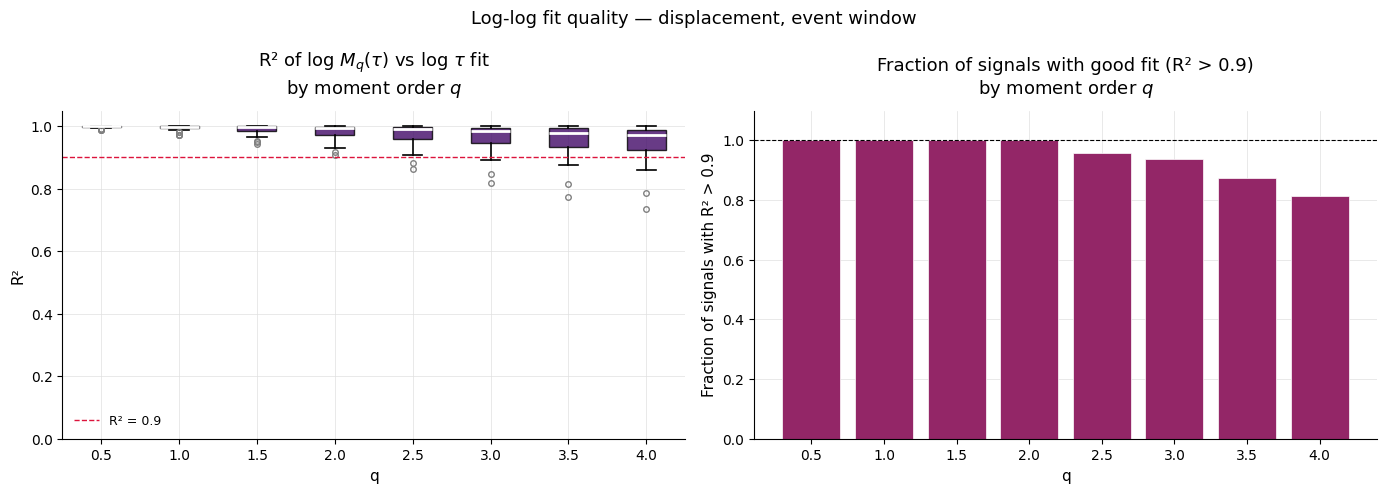

R² summary by q (threshold = 0.9):
  q=0.5: median R² = 1.000 — fraction > 0.9 = 1.00
  q=1.0: median R² = 0.999 — fraction > 0.9 = 1.00
  q=1.5: median R² = 0.997 — fraction > 0.9 = 1.00
  q=2.0: median R² = 0.994 — fraction > 0.9 = 1.00
  q=2.5: median R² = 0.990 — fraction > 0.9 = 0.96
  q=3.0: median R² = 0.984 — fraction > 0.9 = 0.94
  q=3.5: median R² = 0.977 — fraction > 0.9 = 0.88
  q=4.0: median R² = 0.971 — fraction > 0.9 = 0.81


In [17]:
logger.info("R² diagnostic — displacement, event window...")
plot_r2_diagnostic(
    df_exponents_disp_event,
    title_suffix='displacement, event window',
    threshold=0.9,
    output_path=FIGURES_DIR / 'scaling' / 'displacement' / 'event_window' / 'exponents' / 'r2_diagnostic.pdf'
)

INFO | Universal rescaling plot — displacement, event window...


Saved: ../figures/03_single_signal/scaling/displacement/event_window/exponents/universal_rescaling.pdf


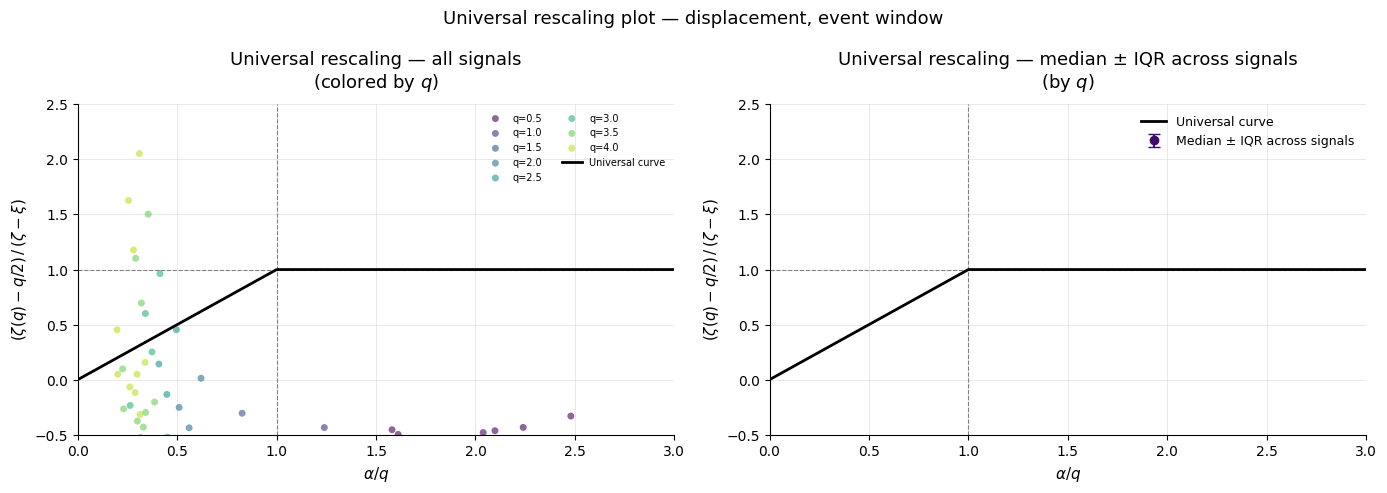

Fraction of points within 0.2 of universal curve: 0.01
Median residual from universal curve: 2.777


In [18]:
logger.info("Universal rescaling plot — displacement, event window...")
df_heavy_tail_results = pd.read_parquet('../data/processed/heavy_tail_results.parquet')
plot_universal_rescaling(
    df_exponents_disp_event,
    df_piecewise_disp_event,
    df_heavy_tail_results,
    title_suffix='displacement, event window',
    output_path=FIGURES_DIR / 'scaling' / 'displacement' / 'event_window' / 'exponents' / 'universal_rescaling.pdf'
)

#### Increment distributions and tail exponents

The empirical CCDF of $|\Delta x(\tau)|$ is plotted in log-log scale for
six representative time scales $\tau \in \{10, 100, 500, 1000, 3000, 5000\}$
samples. The tail exponent is estimated independently via the Hill estimator
and via a linear fit on the log-log CCDF (top 10% of values).

In [19]:
logger.info("Computing increment tail exponents — displacement, event window...")
tau_values_plot = [1, 2, 6, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 300, 400, 500]
df_tail_disp_event = compute_increment_tail_exponents(
    df_increments_disp_event, tau_values_plot=tau_values_plot)
try:
    df_tail_disp_event.to_parquet(
        '../data/processed/increment_tail_disp_event.parquet', index=False)
    logger.info(f"Tail exponents saved: {df_tail_disp_event.shape}")
except Exception as e:
    logger.error(f"Error saving tail exponents: {e}")

logger.info("Plotting increment distributions...")
plot_increment_distributions(
    df_increments_disp_event, df_tail_disp_event,
    tau_values_plot=tau_values_plot,
    output_dir=FIGURES_DIR / 'scaling' / 'displacement' / 'event_window' / 'increments')

INFO | Computing increment tail exponents — displacement, event window...
INFO | Tail exponents saved: (384, 8)
INFO | Plotting increment distributions...


Individual plots saved: 48/48


/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/src/plots.py:1018: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/src/plots.py:1019: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(output_dir, 'increments_summary_ccdf.pdf'), bbox_inches='tight')
/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/src/plots.py:1019: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(os.path.join(output_dir, 'increments_summary_ccdf.pdf'), bbox_inches='tight')


Summary CCDF saved.
Summary exponents saved.
Hill vs fit scatter saved.


## 4. Summary

A summary table collects the main results from all analyses for each signal.
For the moment scaling columns, results from the displacement version (Section 3.3)
are reported as the physically most meaningful choice.

| Column | Description |
|--------|-------------|
| `kurtosis` | Excess kurtosis $\kappa$ |
| `skewness` | Skewness $\gamma$ |
| `non_gaussian` | Anderson-Darling test result ($\alpha = 0.05$) |
| `best_fit_aic` | Best fitting distribution by AIC |
| `student_t_df` | Student-$t$ degrees of freedom $\nu$ |
| `power_law_exp` | Power law exponent $\hat{\alpha}$ (Hill estimator) |
| `q_break` | Piecewise scaling breakpoint $q^*$ |
| `slope_low` | Scaling slope for $q \leq q^*$ |
| `slope_high` | Scaling slope for $q > q^*$ |
| `beta` | Autocorrelation scaling exponent $\beta$ |


### 4.1 Acceleration

### 4.2 Velocity

### 4.3 Displacement